In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Libraries imported successfully.


In [2]:
file_path = "850101.xlsx"

raw = pd.read_excel(
    file_path,
    sheet_name="Data1",
    header=None
)

print("Raw shape:", raw.shape)

display(raw.iloc[:15, :8])

Raw shape: (529, 22)


,0,1,2,3,4,5,6,7
0,NaN,Turnover ; Total (State) ; Food retailing ;,Turnover ; Total (State) ; Household goods r...,"Turnover ; Total (State) ; Clothing, footwea...",Turnover ; Total (State) ; Department stores ;,Turnover ; Total (State) ; Other retailing ;,"Turnover ; Total (State) ; Cafes, restaurant...",Turnover ; Total (State) ; Total (Industry) ;
1,Unit,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions
2,Series Type,Original,Original,Original,Original,Original,Original,Original
3,Data Type,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW
4,Frequency,Month,Month,Month,Month,Month,Month,Month
5,Collection Month,1,1,1,1,1,1,1
6,Series Start,1982-04-01 00:00:00,1982-04-01 00:00:00,1982-04-01 00:00:00,1982-04-01 00:00:00,1982-04-01 00:00:00,1982-04-01 00:00:00,1982-04-01 00:00:00
7,Series End,2025-06-01 00:00:00,2025-06-01 00:00:00,2025-06-01 00:00:00,2025-06-01 00:00:00,2025-06-01 00:00:00,2025-06-01 00:00:00,2025-06-01 00:00:00
8,No. Obs,519,519,519,519,519,519,519
9,Series ID,A3348591K,A3348600A,A3348609W,A3348618X,A3348627A,A3348636C,A3348582J


In [3]:
abs_df = raw.iloc[10:, [0, 1]].copy()

abs_df.columns = ["Date", "Food_Retailing_Turnover"]


abs_df["Date"] = pd.to_datetime(abs_df["Date"], errors="coerce")

abs_df["Food_Retailing_Turnover"] = pd.to_numeric(

    abs_df["Food_Retailing_Turnover"],

    errors="coerce"

)


abs_df = abs_df.dropna().reset_index(drop=True)

print("Clean ABS dataset shape:", abs_df.shape)

print("\nDate range:")

print(abs_df["Date"].min(), "to", abs_df["Date"].max())

display(abs_df.head())

display(abs_df.tail())

Clean ABS dataset shape: (519, 2)

Date range:
1982-04-01 00:00:00 to 2025-06-01 00:00:00


,Date,Food_Retailing_Turnover
0,1982-04-01,1162.6
1,1982-05-01,1150.9
2,1982-06-01,1160.0
3,1982-07-01,1206.4
4,1982-08-01,1152.5


,Date,Food_Retailing_Turnover
514,2025-02-01,13589.6
515,2025-03-01,15149.9
516,2025-04-01,14530.8
517,2025-05-01,14747.0
518,2025-06-01,14095.0


In [4]:
print("Descriptive statistics:")
display(abs_df["Food_Retailing_Turnover"].describe())

print("\nMissing values:")
print(abs_df.isnull().sum())

Descriptive statistics:


count      519.000000
mean      6376.695568
std       4036.028638
min       1150.900000
25%       2788.750000
50%       5498.800000
75%       9547.450000
max      17040.300000
Name: Food_Retailing_Turnover, dtype: float64


Missing values:
Date                       0
Food_Retailing_Turnover    0
dtype: int64


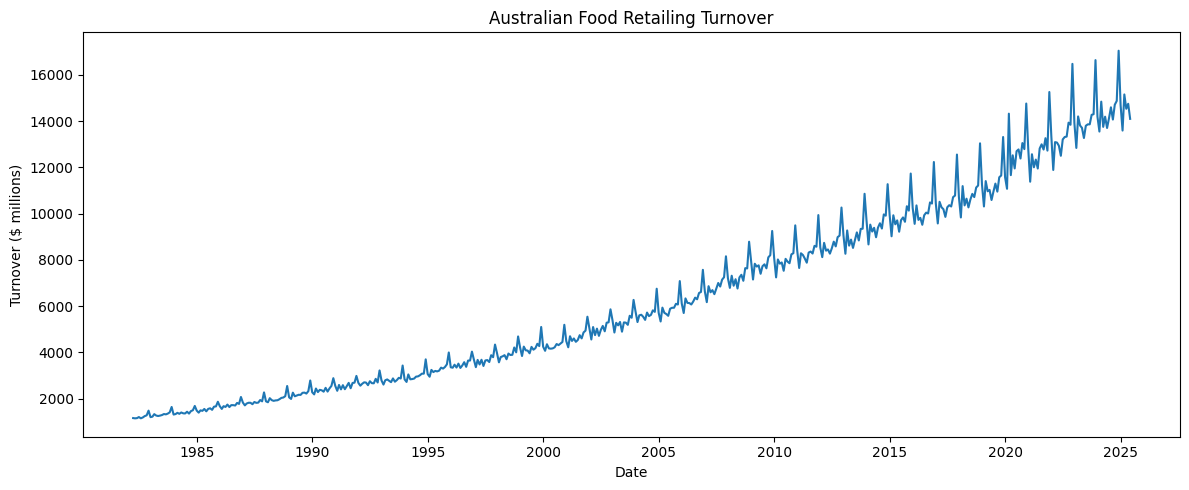

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    abs_df["Date"],
    abs_df["Food_Retailing_Turnover"]
)

plt.xlabel("Date")
plt.ylabel("Turnover ($ millions)")
plt.title("Australian Food Retailing Turnover")

plt.tight_layout()
plt.show()

In [6]:
abs_model = abs_df.copy()

abs_model["Year"] = abs_model["Date"].dt.year
abs_model["Month"] = abs_model["Date"].dt.month
abs_model["Quarter"] = abs_model["Date"].dt.quarter

abs_model["Time_Index"] = np.arange(len(abs_model))

abs_model["Lag_1"] = abs_model["Food_Retailing_Turnover"].shift(1)
abs_model["Lag_3"] = abs_model["Food_Retailing_Turnover"].shift(3)
abs_model["Lag_6"] = abs_model["Food_Retailing_Turnover"].shift(6)
abs_model["Lag_12"] = abs_model["Food_Retailing_Turnover"].shift(12)

abs_model["Rolling_Mean_3"] = (
    abs_model["Food_Retailing_Turnover"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

abs_model["Rolling_Mean_12"] = (
    abs_model["Food_Retailing_Turnover"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

abs_model = abs_model.dropna().reset_index(drop=True)

print("Model dataset shape:", abs_model.shape)

display(abs_model.head())

Model dataset shape: (507, 12)


,Date,Food_Retailing_Turnover,Year,Month,Quarter,Time_Index,Lag_1,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_12
0,1983-04-01,1270.9,1983,4,2,12,1332.4,1202.8,1247.4,1162.6,1253.133333,1232.725000
1,1983-05-01,1251.7,1983,5,2,13,1270.9,1224.2,1280.7,1150.9,1275.833333,1241.750000
2,1983-06-01,1269.3,1983,6,2,14,1251.7,1332.4,1483.7,1160.0,1285.000000,1250.150000
3,1983-07-01,1292.8,1983,7,3,15,1269.3,1270.9,1202.8,1206.4,1263.966667,1259.258333
4,1983-08-01,1337.0,1983,8,3,16,1292.8,1251.7,1224.2,1152.5,1271.266667,1266.458333


In [7]:
features = [
    "Year",
    "Month",
    "Quarter",
    "Time_Index",
    "Lag_1",
    "Lag_3",
    "Lag_6",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_12"
]

target = "Food_Retailing_Turnover"

X = abs_model[features]
y = abs_model[target]

split_index = int(len(abs_model) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(abs_model["Date"].iloc[0], "to",
      abs_model["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(abs_model["Date"].iloc[split_index], "to",
      abs_model["Date"].iloc[-1])

Training observations: 405
Testing observations: 102

Training period:
1983-04-01 00:00:00 to 2016-12-01 00:00:00

Testing period:
2017-01-01 00:00:00 to 2025-06-01 00:00:00


In [8]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [9]:
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBOOST RESULTS - ABS FOOD RETAILING")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

XGBOOST RESULTS - ABS FOOD RETAILING
MAE  : 1428.1670
RMSE : 1878.0849
R²   : -0.2803


In [10]:
results_abs = pd.DataFrame({
    "Date": abs_model.iloc[split_index:]["Date"].values,
    "Actual Turnover": y_test.values,
    "Predicted Turnover": y_pred
})

display(results_abs.head(12))

,Date,Actual Turnover,Predicted Turnover
0,2017-01-01,10431.5,10820.095703
1,2017-02-01,9574.6,10122.928711
2,2017-03-01,10510.3,10813.604492
3,2017-04-01,10274.1,10000.575195
4,2017-05-01,10189.7,10048.713867
5,2017-06-01,9857.6,10063.346680
6,2017-07-01,10272.8,10217.144531
7,2017-08-01,10363.7,10415.539062
8,2017-09-01,10307.9,10243.261719
9,2017-10-01,10710.9,10858.519531


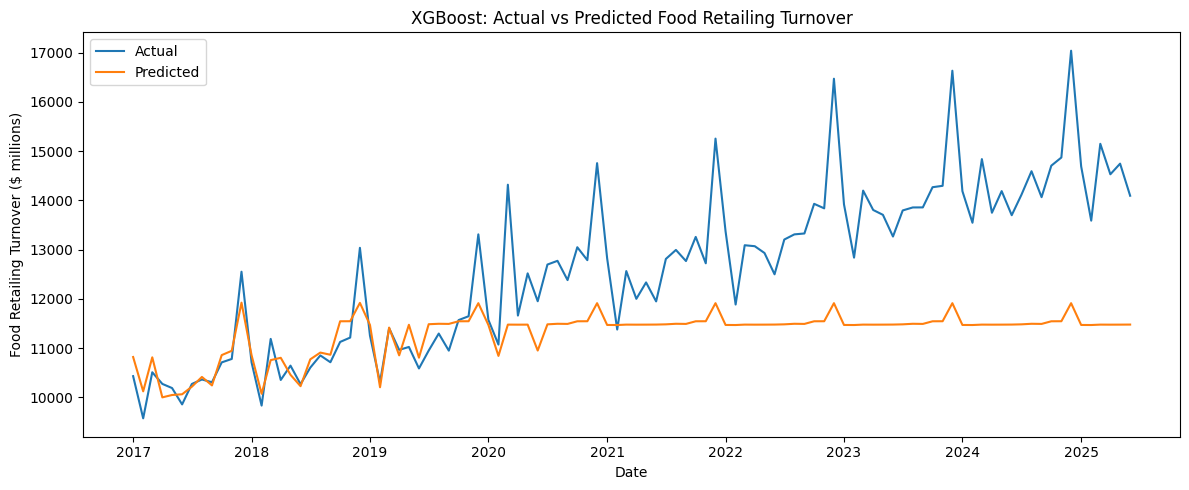

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    results_abs["Date"],
    results_abs["Actual Turnover"],
    label="Actual"
)

plt.plot(
    results_abs["Date"],
    results_abs["Predicted Turnover"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Food Retailing Turnover ($ millions)")
plt.title("XGBoost: Actual vs Predicted Food Retailing Turnover")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature importance:")
display(importance_df)

Feature importance:


,Feature,Importance
7,Lag_12,0.707295
3,Time_Index,0.243095
9,Rolling_Mean_12,0.022691
8,Rolling_Mean_3,0.008813
5,Lag_3,0.008645
4,Lag_1,0.006239
1,Month,0.001340
0,Year,0.000960
2,Quarter,0.000525
6,Lag_6,0.000397


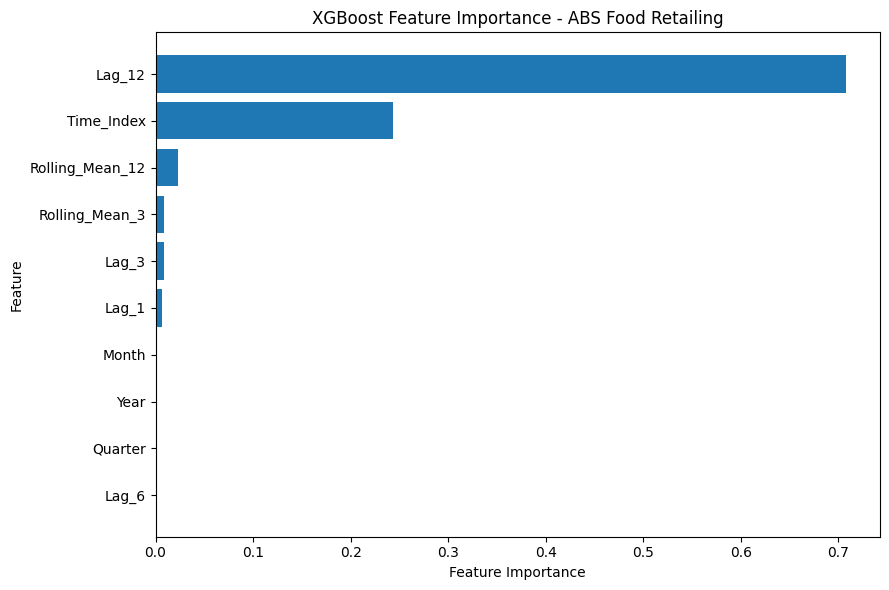

In [13]:
top_features = importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance - ABS Food Retailing")

plt.tight_layout()
plt.show()

In [14]:
# Naive forecast:
naive_predictions = abs_model["Food_Retailing_Turnover"].shift(1)

naive_test = naive_predictions.iloc[split_index:]
actual_test = abs_model["Food_Retailing_Turnover"].iloc[split_index:]

naive_mae = mean_absolute_error(
    actual_test,
    naive_test
)

naive_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        naive_test
    )
)

naive_r2 = r2_score(
    actual_test,
    naive_test
)

print("======================================")
print("NAIVE BASELINE - ABS FOOD RETAILING")
print("======================================")
print(f"MAE  : {naive_mae:.4f}")
print(f"RMSE : {naive_rmse:.4f}")
print(f"R²   : {naive_r2:.4f}")

NAIVE BASELINE - ABS FOOD RETAILING
MAE  : 824.6049
RMSE : 1117.9253
R²   : 0.5464


In [15]:
# IMPROVED ABS MODEL
# Predict Year-on-Year Turnover Growth

growth_df = abs_df.copy()

# Year-on-year percentage growth
growth_df["YoY_Growth"] = (
    growth_df["Food_Retailing_Turnover"]
    .pct_change(12) * 100
)

growth_df["Growth_Lag_1"] = growth_df["YoY_Growth"].shift(1)
growth_df["Growth_Lag_3"] = growth_df["YoY_Growth"].shift(3)
growth_df["Growth_Lag_6"] = growth_df["YoY_Growth"].shift(6)
growth_df["Growth_Lag_12"] = growth_df["YoY_Growth"].shift(12)

growth_df["Month"] = growth_df["Date"].dt.month
growth_df["Quarter"] = growth_df["Date"].dt.quarter

growth_df["Growth_Rolling_3"] = (
    growth_df["YoY_Growth"]
    .shift(1)
    .rolling(3)
    .mean()
)

growth_df["Growth_Rolling_12"] = (
    growth_df["YoY_Growth"]
    .shift(1)
    .rolling(12)
    .mean()
)

growth_df = growth_df.dropna().reset_index(drop=True)

print("Growth modelling dataset:", growth_df.shape)

display(
    growth_df[
        [
            "Date",
            "Food_Retailing_Turnover",
            "YoY_Growth"
        ]
    ].head(15)
)

Growth modelling dataset: (495, 11)


,Date,Food_Retailing_Turnover,YoY_Growth
0,1984-04-01,1346.5,5.948540
1,1984-05-01,1404.3,12.191420
2,1984-06-01,1367.6,7.744426
3,1984-07-01,1361.6,5.321782
4,1984-08-01,1436.7,7.456993
5,1984-09-01,1355.6,2.479589
6,1984-10-01,1462.7,7.916482
7,1984-11-01,1501.4,6.414345
8,1984-12-01,1686.6,2.697437
9,1985-01-01,1484.7,12.947889


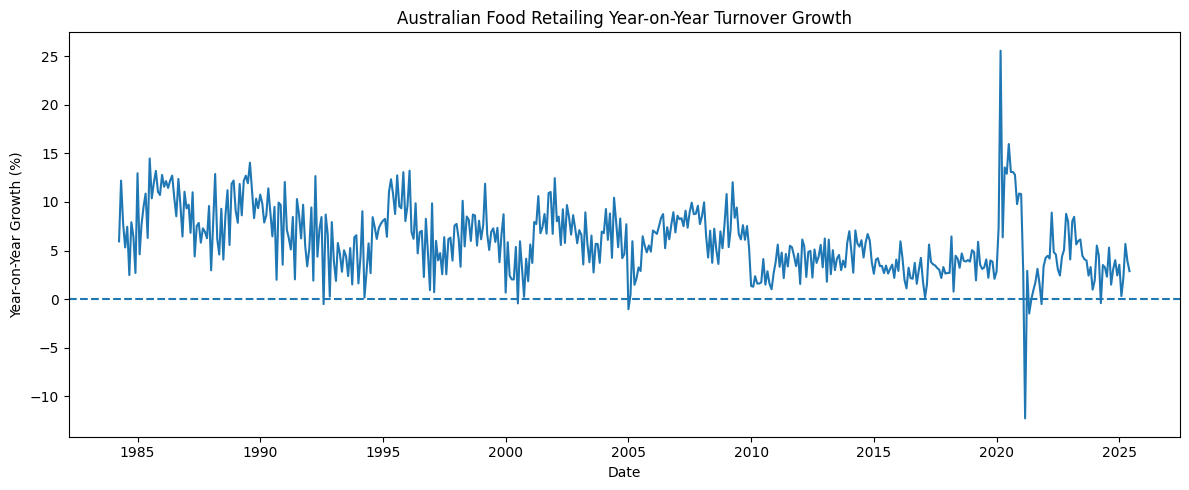

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    growth_df["Date"],
    growth_df["YoY_Growth"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Year-on-Year Growth (%)")
plt.title("Australian Food Retailing Year-on-Year Turnover Growth")

plt.tight_layout()
plt.show()

In [17]:
growth_features = [
    "Growth_Lag_1",
    "Growth_Lag_3",
    "Growth_Lag_6",
    "Growth_Lag_12",
    "Growth_Rolling_3",
    "Growth_Rolling_12",
    "Month",
    "Quarter"
]

growth_target = "YoY_Growth"

X_growth = growth_df[growth_features]
y_growth = growth_df[growth_target]

split_index = int(len(growth_df) * 0.80)

X_train_growth = X_growth.iloc[:split_index]
X_test_growth = X_growth.iloc[split_index:]

y_train_growth = y_growth.iloc[:split_index]
y_test_growth = y_growth.iloc[split_index:]

print("Training observations:", len(X_train_growth))
print("Testing observations:", len(X_test_growth))

print("\nTraining period:")
print(
    growth_df["Date"].iloc[0],
    "to",
    growth_df["Date"].iloc[split_index - 1]
)

print("\nTesting period:")
print(
    growth_df["Date"].iloc[split_index],
    "to",
    growth_df["Date"].iloc[-1]
)

Training observations: 396
Testing observations: 99

Training period:
1984-04-01 00:00:00 to 2017-03-01 00:00:00

Testing period:
2017-04-01 00:00:00 to 2025-06-01 00:00:00


In [18]:
xgb_growth = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_growth.fit(
    X_train_growth,
    y_train_growth
)

print("Growth XGBoost training completed.")

Growth XGBoost training completed.


In [25]:
growth_pred = xgb_growth.predict(X_test_growth)

growth_mae = mean_absolute_error(
    y_test_growth,
    growth_pred
)
growth_rmse = np.sqrt(

    mean_squared_error(

        y_test_growth,

        growth_pred

    )

)
# Naive baseline:
# predict current YoY growth using previous month's YoY growth

naive_growth = growth_df["YoY_Growth"].shift(1)

naive_growth_test = naive_growth.iloc[split_index:]

baseline_growth_mae = mean_absolute_error(
    y_test_growth,
    naive_growth_test
)

baseline_growth_rmse = np.sqrt(
    mean_squared_error(
        y_test_growth,
        naive_growth_test
    )
)

baseline_growth_r2 = r2_score(
    y_test_growth,
    naive_growth_test
)

print("NAIVE BASELINE - YOY GROWTH")

print(f"MAE  : {baseline_growth_mae:.4f}")
print(f"RMSE : {baseline_growth_rmse:.4f}")
print(f"R²   : {baseline_growth_r2:.4f}")


growth_r2 = r2_score(
    y_test_growth,
    growth_pred
)

print("XGBOOST - YOY FOOD RETAILING GROWTH")

print(f"MAE  : {growth_mae:.4f}")
print(f"RMSE : {growth_rmse:.4f}")
print(f"R²   : {growth_r2:.4f}")

NAIVE BASELINE - YOY GROWTH
MAE  : 2.3919
RMSE : 4.1704
R²   : 0.0036
XGBOOST - YOY FOOD RETAILING GROWTH
MAE  : 2.2172
RMSE : 3.9552
R²   : 0.1038


In [26]:
growth_importance = pd.DataFrame({
    "Feature": growth_features,
    "Importance": xgb_growth.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(growth_importance)

,Feature,Importance
4,Growth_Rolling_3,0.317228
1,Growth_Lag_3,0.238519
2,Growth_Lag_6,0.103516
0,Growth_Lag_1,0.084740
3,Growth_Lag_12,0.082244
5,Growth_Rolling_12,0.065855
6,Month,0.058265
7,Quarter,0.049634


In [27]:
growth_importance = pd.DataFrame({
    "Feature": growth_features,
    "Importance": xgb_growth.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(growth_importance)

,Feature,Importance
4,Growth_Rolling_3,0.317228
1,Growth_Lag_3,0.238519
2,Growth_Lag_6,0.103516
0,Growth_Lag_1,0.084740
3,Growth_Lag_12,0.082244
5,Growth_Rolling_12,0.065855
6,Month,0.058265
7,Quarter,0.049634


In [28]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv_growth = TimeSeriesSplit(n_splits=5)

cv_growth_r2 = cross_val_score(
    xgb_growth,
    X_growth,
    y_growth,
    cv=tscv_growth,
    scoring="r2"
)

print("Time-Series Cross-Validation R²:")
print(cv_growth_r2)

print("\nMean CV R²:", cv_growth_r2.mean())
print("Standard deviation:", cv_growth_r2.std())

Time-Series Cross-Validation R²:
[-0.36865129  0.12004041  0.37593294 -0.46629925  0.10492312]

Mean CV R²: -0.046810813568149465
Standard deviation: 0.31910081346774
